# ALC speaker analysis

One row per speaker of the Alcohol Language Corpus, produced by `python -m alc.speakers ALC annotation_analysis.csv`. The corpus itself is licensed through the BAS and is not in this repository; this CSV is enough to reproduce the plots below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('annotation_analysis.csv', dtype={'spn': str})
df['bac'] = df['bak'] * 1000  # stored as a fraction; per mille is the usual unit
print(f'{len(df)} speakers')
df.head()

162 speakers


,spn,alc,sex,age,acc,drh,aak,bak,ges,ces,wea,bac
0,558,na,F,26,NW,moderate,0.00000,0.00000,f5,r1,SUN,0.00
1,047,a,M,28,BY,light,0.00143,0.00125,f5,r1,SUN,1.25
2,594,na,F,59,BY,light,0.00000,0.00000,f2,r1,SUN,0.00
3,020,a,M,32,BE,light,0.00112,0.00123,f5,r1,SUN,1.23
4,018,na,F,27,BW,moderate,0.00000,0.00000,f8,r4,SUN,0.00


## Who is in the corpus

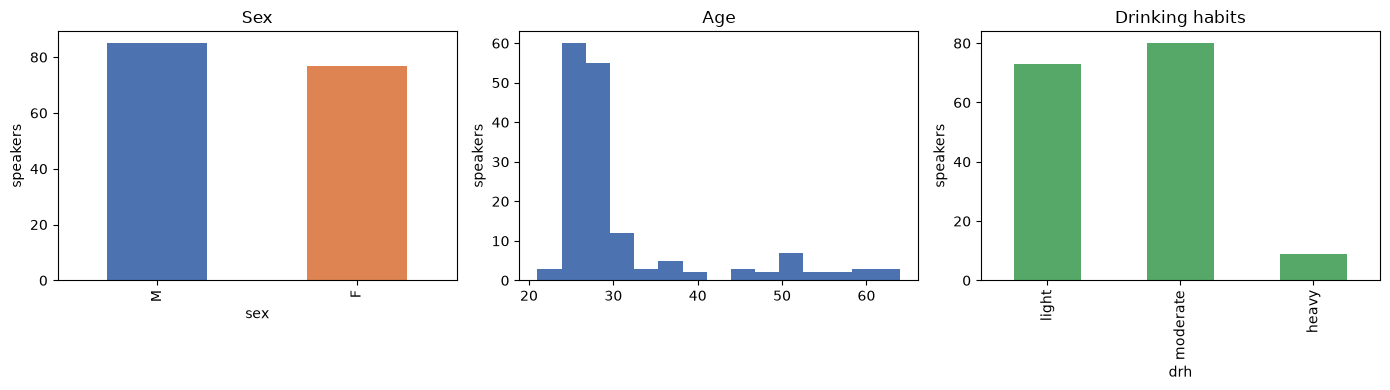

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['sex'].value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'], title='Sex')
df['age'].plot.hist(ax=axes[1], bins=15, color='#4C72B0', title='Age')
df['drh'].value_counts().reindex(['light', 'moderate', 'heavy']).plot.bar(ax=axes[2], color='#55A868', title='Drinking habits')
for ax in axes: ax.set_ylabel('speakers')
fig.tight_layout()
fig.savefig('docs/speakers.png', dpi=120)

## Blood alcohol concentration

The `alc` label is `a` (alcoholised) for BAC above 0.5 per mille, `na` below it, and `cna` for sober control recordings. Speakers were asked to reach a target BAC before the intoxicated session.

count    90.000000
mean      0.874556
std       0.284104
min       0.230000
25%       0.682500
50%       0.845000
75%       1.087500
max       1.470000
Name: bac, dtype: float64

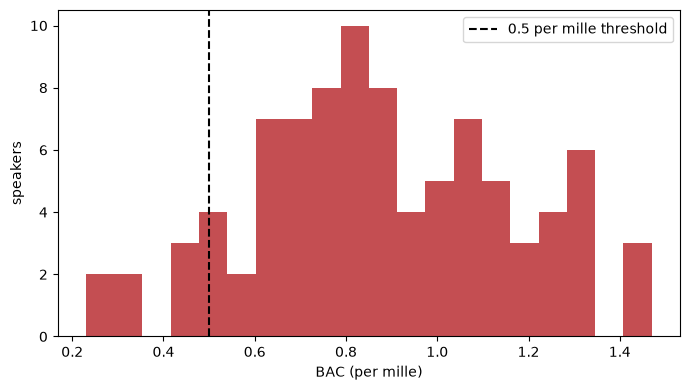

In [3]:
intox = df[df['bac'] > 0]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(intox['bac'], bins=20, color='#C44E52')
ax.axvline(0.5, color='k', linestyle='--', label='0.5 per mille threshold')
ax.set_xlabel('BAC (per mille)'); ax.set_ylabel('speakers'); ax.legend()
fig.tight_layout()
fig.savefig('docs/bac.png', dpi=120)
intox['bac'].describe()

## BAC by sex and drinking habits

In [4]:
intox.groupby(['sex', 'drh'])['bac'].agg(['count', 'mean', 'median']).round(3)

count   mean  median
sex drh                           
F   light        26  0.851    0.83
    moderate     15  0.910    0.86
M   heavy         3  0.807    0.81
    light        17  0.938    0.98
    moderate     29  0.848    0.83